# Machine Learning Models - Training & Testing (Dynamic Dataset Control)
## Network Intrusion Detection System

### Features:
- **Per-model dataset size control** - Set different sample sizes for each model
- **Model-specific directories** - Each model saves to its own subdirectory
- **Optimized for slow models** - Use smaller datasets for KNN and SVM

### Models:
1. Random Forest (RF)
2. Decision Tree (DT)
3. XGBoost
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Naive Bayes (NB)

In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================
# Set the number of rows to use for each model
# None = use full dataset
# Integer = use that many rows (will be sampled from full dataset)

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    print(f"   {model}: {size_str}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml/


In [3]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, or set a limit

# Initialize lists to store chunks
chunks = []
total_rows = 0

# Read in chunks
print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    # Check if we've reached max rows
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    # If this chunk would exceed MAX_ROWS, truncate it
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    # Progress update every 5 chunks
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

# Combine chunks
print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks  # Free memory

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")
print(f"\nFirst few columns: {list(df_full.columns)[:5]}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

In [14]:
# Display first few rows
print("📊 First 5 rows:")
display(df_full.head(20))

# Memory usage
print(f"\n💾 Memory usage: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data info
print("\n📋 Dataset Info:")
print(f"   Shape: {df_full.shape}")
print(f"   Columns: {len(df_full.columns)}")
print(f"   Data types: {df_full.dtypes.value_counts().to_dict()}")

📊 First 5 rows:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label_Binary
0,0,0,112641719,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320859.5,56320958.0,56320761.0,0
1,0,0,112641466,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320733.0,56320814.0,56320652.0,0
2,0,0,112638623,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56319311.5,56319525.0,56319098.0,0
3,22,6,6453966,15,10,1239.0,2273.0,744.0,82.600000,196.741237,...,10,2273,65535,233,6,32,0.0,0.0,0.0,0
4,22,6,8804066,14,11,1143.0,2209.0,744.0,81.642857,203.745545,...,11,2209,5808,233,6,32,0.0,0.0,0.0,0
5,22,6,6989341,16,12,1239.0,2273.0,744.0,77.437500,190.831154,...,12,2273,5808,234,7,20,0.0,0.0,0.0,0
6,0,0,112640480,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320240.0,56320384.0,56320096.0,0
7,0,0,112641244,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320622.0,56320666.0,56320578.0,0
8,80,6,476513,5,3,211.0,463.0,211.0,42.200000,94.362069,...,3,463,14600,219,1,32,0.0,0.0,0.0,0
9,80,6,475048,5,3,220.0,472.0,220.0,44.000000,98.386991,...,3,472,14600,219,1,32,0.0,0.0,0.0,0



💾 Memory usage: 7183.16 MB

📋 Dataset Info:
   Shape: (16232943, 58)
   Columns: 58
   Data types: {dtype('float64'): 37, dtype('int64'): 21}


📊 Class Distribution:
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64


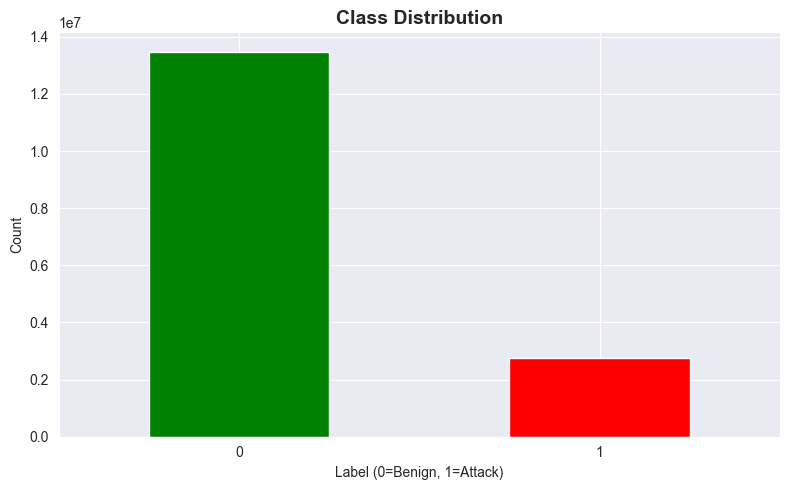


  Benign (0): 13,484,708 (83.07%)
  Attack (1): 2,748,235 (16.93%)


In [4]:
# Class distribution
print("📊 Class Distribution:")
class_counts = df_full['Label_Binary'].value_counts()
print(class_counts)

# Visualize
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Percentages
benign_count = (df_full['Label_Binary'] == 0).sum()
attack_count = (df_full['Label_Binary'] == 1).sum()
benign_pct = benign_count / len(df_full) * 100
attack_pct = attack_count / len(df_full) * 100

print(f"\n  Benign (0): {benign_count:,} ({benign_pct:.2f}%)")
print(f"  Attack (1): {attack_count:,} ({attack_pct:.2f}%)")

In [22]:
df_full.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label_Binary
0,0,0,112641719,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320859.5,56320958.0,56320761.0,0
1,0,0,112641466,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320733.0,56320814.0,56320652.0,0
2,0,0,112638623,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56319311.5,56319525.0,56319098.0,0
3,22,6,6453966,15,10,1239.0,2273.0,744.0,82.600000,196.741237,...,10,2273,65535,233,6,32,0.0,0.0,0.0,0
4,22,6,8804066,14,11,1143.0,2209.0,744.0,81.642857,203.745545,...,11,2209,5808,233,6,32,0.0,0.0,0.0,0


In [5]:
# ========================================
# PREPARE FULL DATASET
# ========================================

print("🔧 Preparing data...")

# Separate features and labels

X_full = df_full.drop(['Label_Binary'], axis=1)
y_full = df_full['Label_Binary']

# Keep only numeric columns
print("\n🔢 Selecting numeric features...")
X_full = X_full.select_dtypes(include=[np.number])

print(f"\n✅ Features shape: {X_full.shape}")
print(f"✅ Labels shape: {y_full.shape}")
print(f"\nNumber of features: {X_full.shape[1]}")

# Free memory
del df_full
print("\n🧹 Freed original dataframe memory")

🔧 Preparing data...

🔢 Selecting numeric features...

✅ Features shape: (16232943, 57)
✅ Labels shape: (16232943,)

Number of features: 57

🧹 Freed original dataframe memory


In [6]:
# ========================================
# MODEL CONFIGURATIONS
# ========================================

models = {
    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        ),
        'use_scaled': False
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ),
        'use_scaled': False
    },
    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=100,
            max_depth=10,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric='logloss'
        ),
        'use_scaled': False
    },
    'KNN': {
        'model': KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1
        ),
        'use_scaled': True
    },
    'SVM': {
        'model': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            random_state=RANDOM_STATE,
            verbose=True
        ),
        'use_scaled': True
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'use_scaled': False
    }
}

print(f"✅ Defined {len(models)} models:")
for model_name in models.keys():
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    size_str = 'Full dataset' if sample_size is None else f'{sample_size:,} rows'
    print(f"   - {model_name} ({size_str})")

✅ Defined 6 models:
   - Random Forest (Full dataset)
   - Decision Tree (Full dataset)
   - XGBoost (Full dataset)
   - KNN (50,000 rows)
   - SVM (100,000 rows)
   - Naive Bayes (Full dataset)


In [16]:
# ========================================
# HELPER FUNCTION: SAMPLE DATA FOR MODEL
# ========================================

def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """
    Get train/test split for a specific model with optional sampling.
    
    Parameters:
    -----------
    X_full : DataFrame
        Full feature dataset
    y_full : Series
        Full target dataset
    model_name : str
        Name of the model (for logging)
    sample_size : int or None
        Number of rows to sample (None = use full dataset)
    test_size : float
        Proportion of test set
    random_state : int
        Random state for reproducibility
    
    Returns:
    --------
    X_train, X_test, y_train, y_test : arrays
        Train and test splits
    """
    
    if sample_size is None:
        # Use full dataset
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        # Sample dataset
        if sample_size > len(X_full):
            print(f"⚠️  Requested {sample_size:,} rows but only {len(X_full):,} available")
            print(f"📊 Using full dataset instead")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            # Stratified sampling to maintain class distribution
            X, _, y, _ = train_test_split(
                X_full, y_full, 
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    # Train-test split
    print(f"🔪 Splitting into train/test ({test_size*100}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test

In [17]:
# ========================================
# TRAIN AND TEST ALL MODELS
# ========================================

results = {}
trained_models = {}

for model_name, model_config in models.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name}")
    print("="*80)
    
    # Create model-specific directory
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")
    
    # Get sample size for this model
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    
    # Get train/test data with optional sampling
    X_train, X_test, y_train, y_test = get_model_data(
        X_full, y_full, 
        model_name, 
        sample_size, 
        TEST_SIZE, 
        RANDOM_STATE
    )
    
    # Feature scaling if needed
    model = model_config['model']
    use_scaled = model_config['use_scaled']
    
    if use_scaled:
        print(f"\n⚖️  Scaling features...")
        scaler = StandardScaler()
        X_train_use = scaler.fit_transform(X_train)
        X_test_use = scaler.transform(X_test)
        
        # Save scaler
        if SAVE_MODELS:
            scaler_path = os.path.join(model_dir, 'scaler.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(scaler, f)
            print(f"✅ Scaler saved: {scaler_path}")
        
        print(f"📊 Using: SCALED features")
    else:
        X_train_use = X_train
        X_test_use = X_test
        print(f"📊 Using: ORIGINAL features")
    
    # Training
    print(f"\n⏱️  Training...")
    start_time = time.time()
    model.fit(X_train_use, y_train)
    train_time = time.time() - start_time
    print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
    
    # Prediction
    print(f"\n🔮 Making predictions...")
    start_time = time.time()
    y_pred = model.predict(X_test_use)
    pred_time = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")
    
    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'train_time': train_time,
        'pred_time': pred_time,
        'confusion_matrix': cm,
        'predictions': y_pred,
        'sample_size': len(X_train) + len(X_test),
        'train_samples': len(X_train),
        'test_samples': len(X_test)
    }
    
    trained_models[model_name] = model
    
    # Print metrics
    print(f"\n📊 RESULTS:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    print(f"\n🕐 TIME:")
    print(f"   Train: {train_time:.2f}s ({train_time/60:.2f} min)")
    print(f"   Test:  {pred_time:.2f}s")
    
    print(f"\n🎯 Confusion Matrix:")
    print(cm)
    
    # Save model
    if SAVE_MODELS:
        model_path = os.path.join(model_dir, 'model.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"\n💾 Model saved: {model_path}")
        
        # Save metadata
        metadata = {
            'model_name': model_name,
            'sample_size': sample_size,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'features': X_train.shape[1],
            'use_scaled': use_scaled,
            'train_time': train_time,
            'metrics': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1
            }
        }
        
        metadata_path = os.path.join(model_dir, 'metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f"💾 Metadata saved: {metadata_path}")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED!")
print("="*80)


🚀 TRAINING: Random Forest
📁 Model directory: trained_models/ml/random_forest\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples
📊 Using: ORIGINAL features

⏱️  Training...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 18.8min finished


✅ Training completed in 1153.23 seconds (19.22 minutes)

🔮 Making predictions...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    7.5s finished


✅ Predictions completed in 11.53 seconds

📊 RESULTS:
   Accuracy:  0.9901
   Precision: 0.9977
   Recall:    0.9436
   F1-Score:  0.9699

🕐 TIME:
   Train: 1153.23s (19.22 min)
   Test:  11.53s

🎯 Confusion Matrix:
[[2695762    1180]
 [  31025  518622]]

💾 Model saved: trained_models/ml/random_forest\model.pkl
💾 Metadata saved: trained_models/ml/random_forest\metadata.pkl

🚀 TRAINING: Decision Tree
📁 Model directory: trained_models/ml/decision_tree\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples
📊 Using: ORIGINAL features

⏱️  Training...
✅ Training completed in 683.57 seconds (11.39 minutes)

🔮 Making predictions...
✅ Predictions completed in 2.68 seconds

📊 RESULTS:
   Accuracy:  0.9901
   Precision: 0.9968
   Recall:    0.9443
   F1-Score:  0.9698

🕐 TIME:
   Train: 683.57s (11.39 min)
   Test:  2.68s

🎯 Confusion Matrix:
[[2695278    1664]
 [  30634  519013]]

💾 Model saved: trained_mod

In [18]:
# ========================================
# PERFORMANCE SUMMARY
# ========================================

# Create summary DataFrame
summary_data = []
for model_name, metrics in results.items():
    summary_data.append({
        'Model': model_name,
        'Sample Size': metrics['sample_size'],
        'Train Samples': metrics['train_samples'],
        'Test Samples': metrics['test_samples'],
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'Train Time (s)': metrics['train_time'],
        'Train Time (min)': metrics['train_time'] / 60,
        'Test Time (s)': metrics['pred_time']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("📊 PERFORMANCE SUMMARY (sorted by F1-Score):")
print("="*100)
display(summary_df.style.background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
    cmap='RdYlGn'
))

# Save summary
if SAVE_MODELS:
    summary_path = os.path.join(BASE_MODEL_DIR, 'training_summary.csv')
    summary_df.to_csv(summary_path, index=False)
    print(f"\n💾 Summary saved to {summary_path}")

📊 PERFORMANCE SUMMARY (sorted by F1-Score):


,Model,Sample Size,Train Samples,Test Samples,Accuracy,Precision,Recall,F1-Score,Train Time (s),Train Time (min),Test Time (s)
0,XGBoost,16232943,12986354,3246589,0.990175,0.998563,0.943325,0.970159,82.770422,1.379507,2.093271
1,Random Forest,16232943,12986354,3246589,0.990080,0.997730,0.943555,0.969886,1153.225137,19.220419,11.533943
2,Decision Tree,16232943,12986354,3246589,0.990052,0.996804,0.944266,0.969824,683.570415,11.392840,2.683334
3,KNN,50000,40000,10000,0.988700,0.987654,0.945068,0.965892,0.013777,0.000230,3.034926
4,SVM,100000,80000,20000,0.977700,0.993620,0.873892,0.929918,27.982355,0.466373,5.900822
5,Naive Bayes,16232943,12986354,3246589,0.274833,0.185706,0.970008,0.311732,30.416145,0.506936,5.918479



💾 Summary saved to trained_models/ml/training_summary.csv


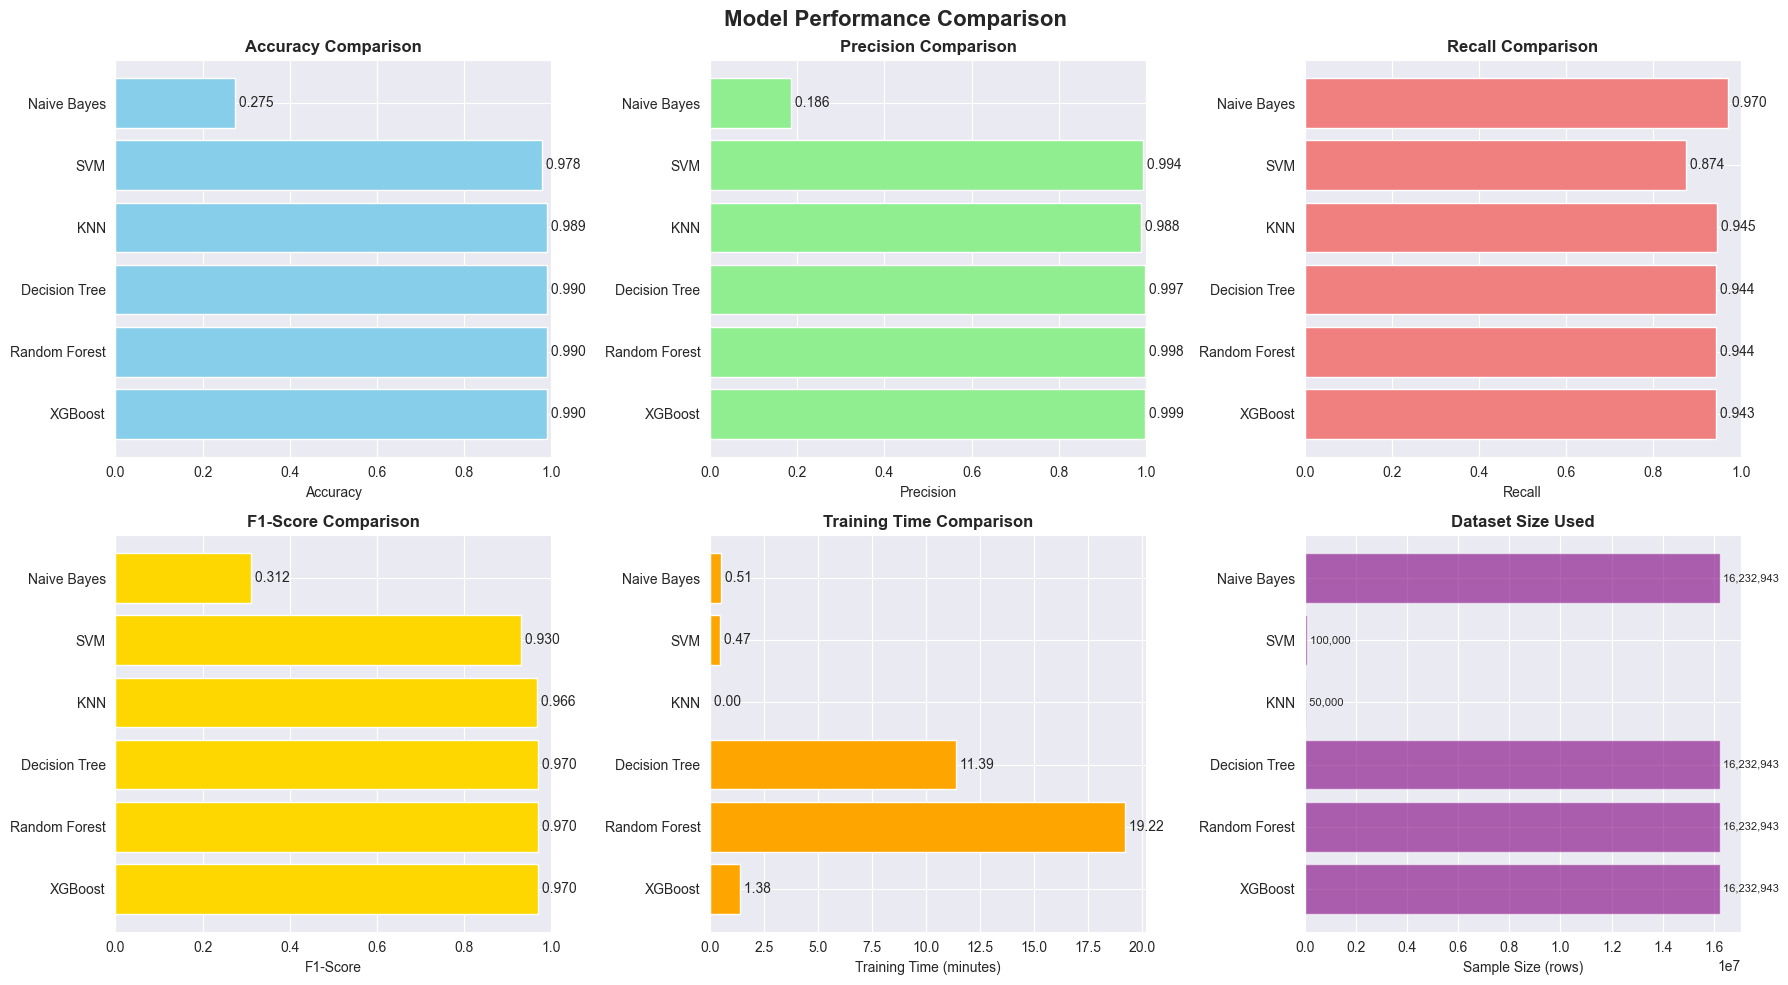


💾 Visualization saved to trained_models/ml/performance_comparison.png


In [19]:
# ========================================
# VISUALIZATION: PERFORMANCE COMPARISON
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].barh(summary_df['Model'], summary_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(summary_df['Accuracy']):
    axes[0, 0].text(v, i, f' {v:.3f}', va='center')

# Precision
axes[0, 1].barh(summary_df['Model'], summary_df['Precision'], color='lightgreen')
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_title('Precision Comparison', fontweight='bold')
axes[0, 1].set_xlim(0, 1)
for i, v in enumerate(summary_df['Precision']):
    axes[0, 1].text(v, i, f' {v:.3f}', va='center')

# Recall
axes[0, 2].barh(summary_df['Model'], summary_df['Recall'], color='lightcoral')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_title('Recall Comparison', fontweight='bold')
axes[0, 2].set_xlim(0, 1)
for i, v in enumerate(summary_df['Recall']):
    axes[0, 2].text(v, i, f' {v:.3f}', va='center')

# F1-Score
axes[1, 0].barh(summary_df['Model'], summary_df['F1-Score'], color='gold')
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score Comparison', fontweight='bold')
axes[1, 0].set_xlim(0, 1)
for i, v in enumerate(summary_df['F1-Score']):
    axes[1, 0].text(v, i, f' {v:.3f}', va='center')

# Training Time
axes[1, 1].barh(summary_df['Model'], summary_df['Train Time (min)'], color='orange')
axes[1, 1].set_xlabel('Training Time (minutes)')
axes[1, 1].set_title('Training Time Comparison', fontweight='bold')
for i, v in enumerate(summary_df['Train Time (min)']):
    axes[1, 1].text(v, i, f' {v:.2f}', va='center')

# Sample Size
axes[1, 2].barh(summary_df['Model'], summary_df['Sample Size'], color='purple', alpha=0.6)
axes[1, 2].set_xlabel('Sample Size (rows)')
axes[1, 2].set_title('Dataset Size Used', fontweight='bold')
for i, v in enumerate(summary_df['Sample Size']):
    axes[1, 2].text(v, i, f' {v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{BASE_MODEL_DIR}performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved to {BASE_MODEL_DIR}performance_comparison.png")

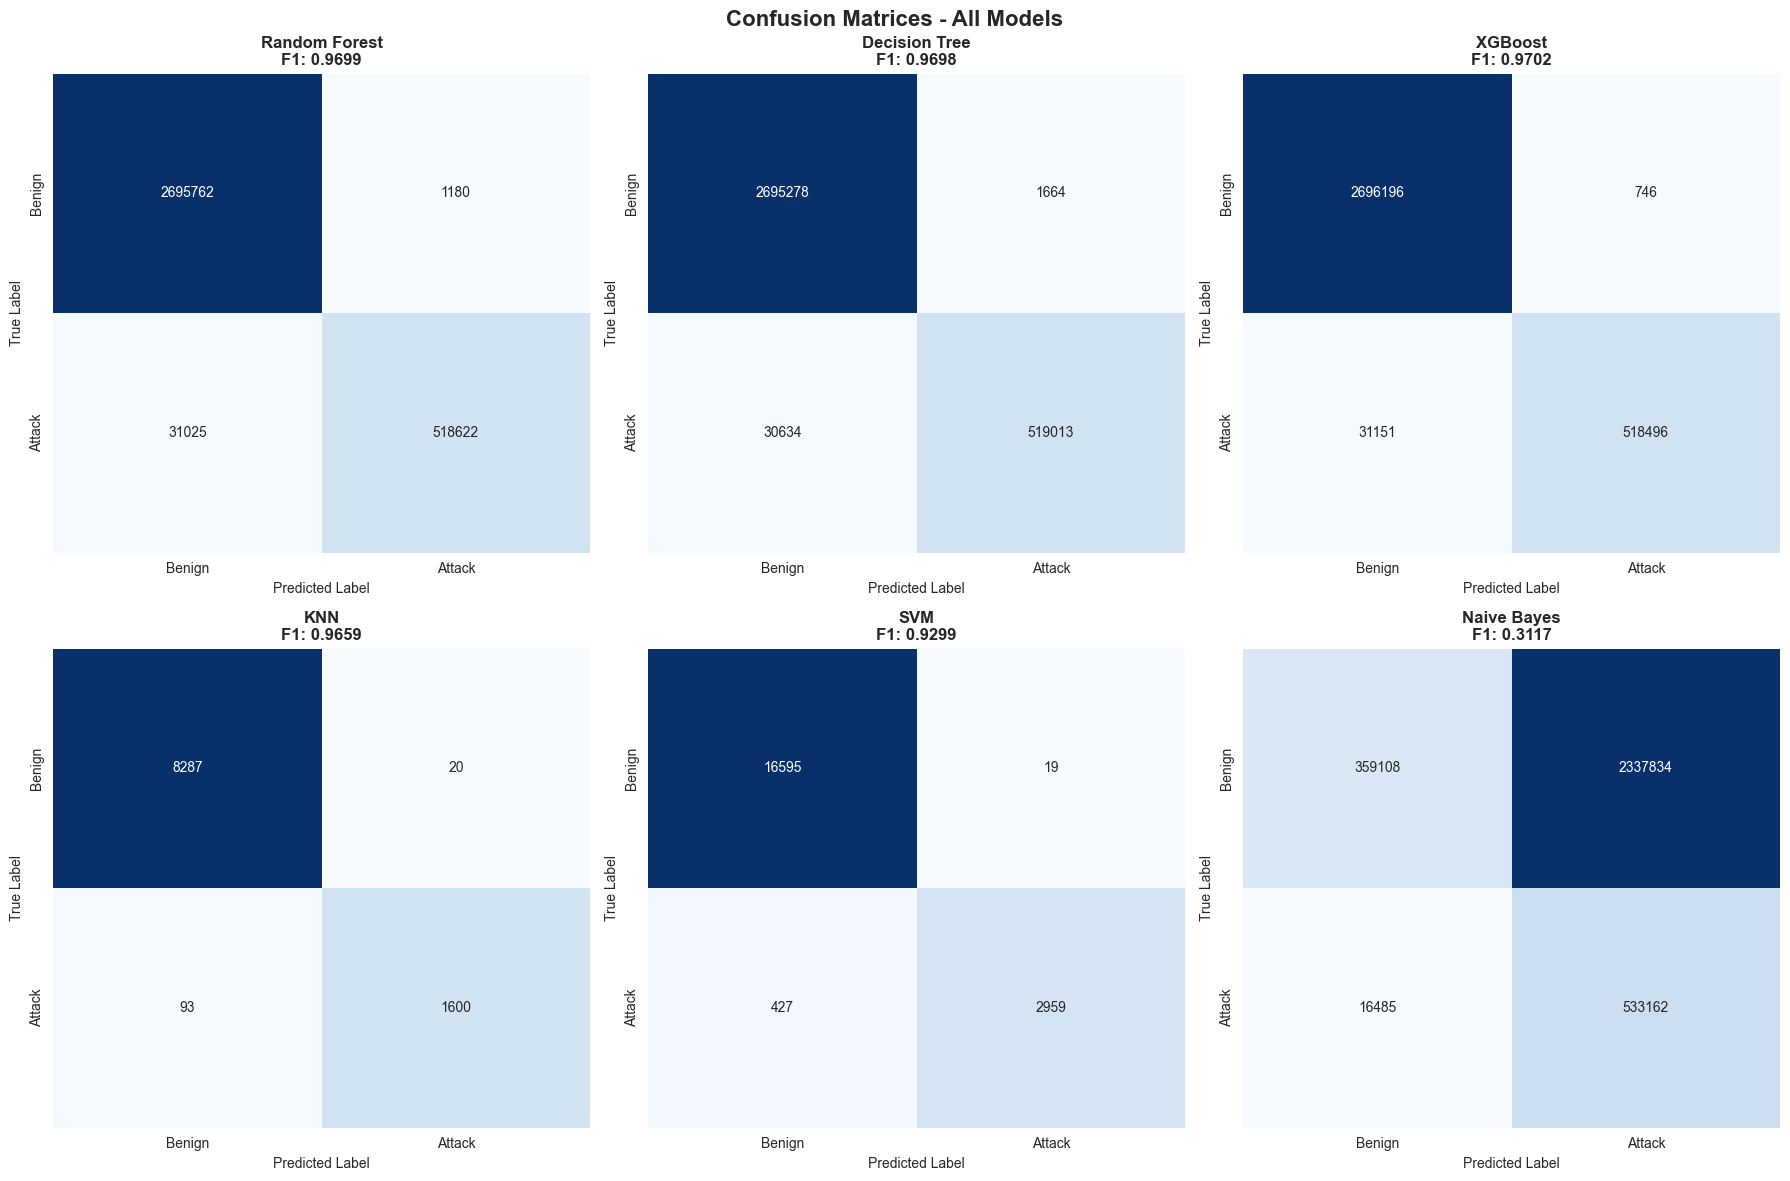


💾 Confusion matrices saved to trained_models/ml/confusion_matrices.png


In [20]:
# ========================================
# CONFUSION MATRICES VISUALIZATION
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

for idx, (model_name, metrics) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    
    cm = metrics['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[row, col], cbar=False,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    
    axes[row, col].set_title(f'{model_name}\nF1: {metrics["f1_score"]:.4f}', 
                             fontweight='bold')
    axes[row, col].set_ylabel('True Label')
    axes[row, col].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{BASE_MODEL_DIR}confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrices saved to {BASE_MODEL_DIR}confusion_matrices.png")

In [21]:
# ========================================
# FINAL SUMMARY
# ========================================

print("\n" + "="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)

print("\n📊 Models Ranked by F1-Score:")
for idx, row in summary_df.iterrows():
    print(f"   {idx+1}. {row['Model']}: {row['F1-Score']:.4f} "
          f"(trained on {row['Sample Size']:,} samples)")

print(f"\n📁 All models saved to: {BASE_MODEL_DIR}")
print("\n📁 Directory structure:")
for model_name in models.keys():
    model_dir = model_name.lower().replace(' ', '_')
    print(f"   {BASE_MODEL_DIR}{model_dir}/")
    print(f"      ├── model.pkl")
    print(f"      ├── metadata.pkl")
    if models[model_name]['use_scaled']:
        print(f"      └── scaler.pkl")

print("\n" + "="*80)


🎉 TRAINING COMPLETE!

📊 Models Ranked by F1-Score:
   1. XGBoost: 0.9702 (trained on 16,232,943 samples)
   2. Random Forest: 0.9699 (trained on 16,232,943 samples)
   3. Decision Tree: 0.9698 (trained on 16,232,943 samples)
   4. KNN: 0.9659 (trained on 50,000 samples)
   5. SVM: 0.9299 (trained on 100,000 samples)
   6. Naive Bayes: 0.3117 (trained on 16,232,943 samples)

📁 All models saved to: trained_models/ml/

📁 Directory structure:
   trained_models/ml/random_forest/
      ├── model.pkl
      ├── metadata.pkl
   trained_models/ml/decision_tree/
      ├── model.pkl
      ├── metadata.pkl
   trained_models/ml/xgboost/
      ├── model.pkl
      ├── metadata.pkl
   trained_models/ml/knn/
      ├── model.pkl
      ├── metadata.pkl
      └── scaler.pkl
   trained_models/ml/svm/
      ├── model.pkl
      ├── metadata.pkl
      └── scaler.pkl
   trained_models/ml/naive_bayes/
      ├── model.pkl
      ├── metadata.pkl



In [7]:
import pickle
import os
import numpy as np

# المسار بتاع موديل XGBoost
MODEL_DIR = "trained_models/ml/xgboost/"

model_path = os.path.join(MODEL_DIR, "model.pkl")
metadata_path = os.path.join(MODEL_DIR, "metadata.pkl")

# Load model
with open(model_path, "rb") as f:
    xgb_model = pickle.load(f)

# Load metadata (اختياري بس مفيد)
with open(metadata_path, "rb") as f:
    metadata = pickle.load(f)

print("✅ Model loaded:", metadata["model_name"])
print("✅ Number of features:", metadata["features"])


✅ Model loaded: XGBoost
✅ Number of features: 57


In [8]:
import pickle
import os
import numpy as np

MODEL_DIR = "trained_models/ml/xgboost/"

with open(os.path.join(MODEL_DIR, "model.pkl"), "rb") as f:
    model = pickle.load(f)

with open(os.path.join(MODEL_DIR, "metadata.pkl"), "rb") as f:
    metadata = pickle.load(f)

print("Model loaded:", metadata["model_name"])
print("Expected features:", metadata["features"])


Model loaded: XGBoost
Expected features: 57


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (12986354, 57)
Test shape: (3246589, 57)


In [10]:
from xgboost import XGBClassifier

RANDOM_STATE = 42

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss'
)

print("✅ XGBoost model initialized")


✅ XGBoost model initialized


In [16]:
# Assuming X_train, y_train, and X_test are already defined in previous cells

# 1. Initialize the model
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42)

# 2. Fit the model (This is the missing step causing the error)
print("Training the XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Model trained successfully!")

# 3. Now you can safely run your prediction code
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Proceed with evaluation
print("Predictions completed.")

Training the XGBoost model...
Model trained successfully!
Predictions completed.



Model Accuracy: 0.9901
ROC-AUC Score: 0.9920

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99   2696942
           1       1.00      0.94      0.97    549647

    accuracy                           0.99   3246589
   macro avg       0.99      0.97      0.98   3246589
weighted avg       0.99      0.99      0.99   3246589



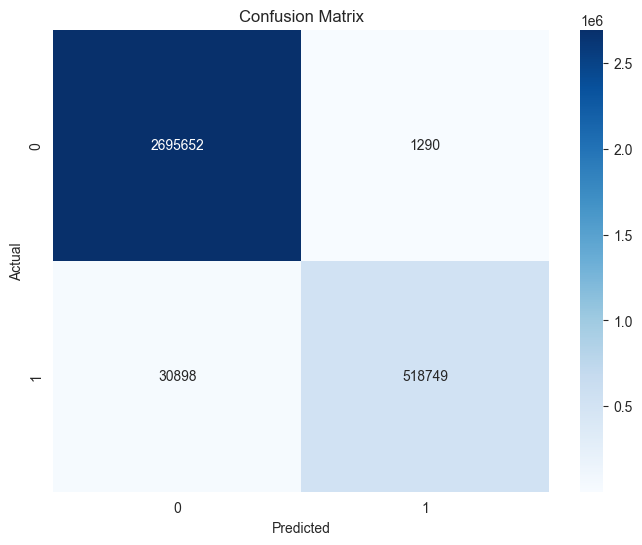

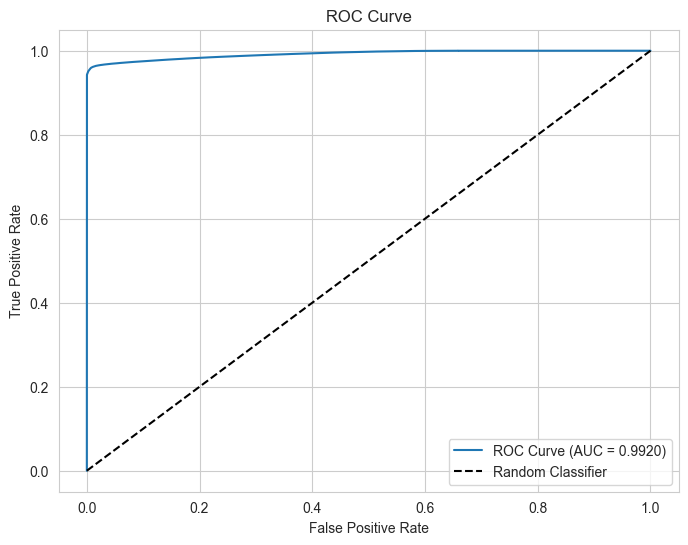

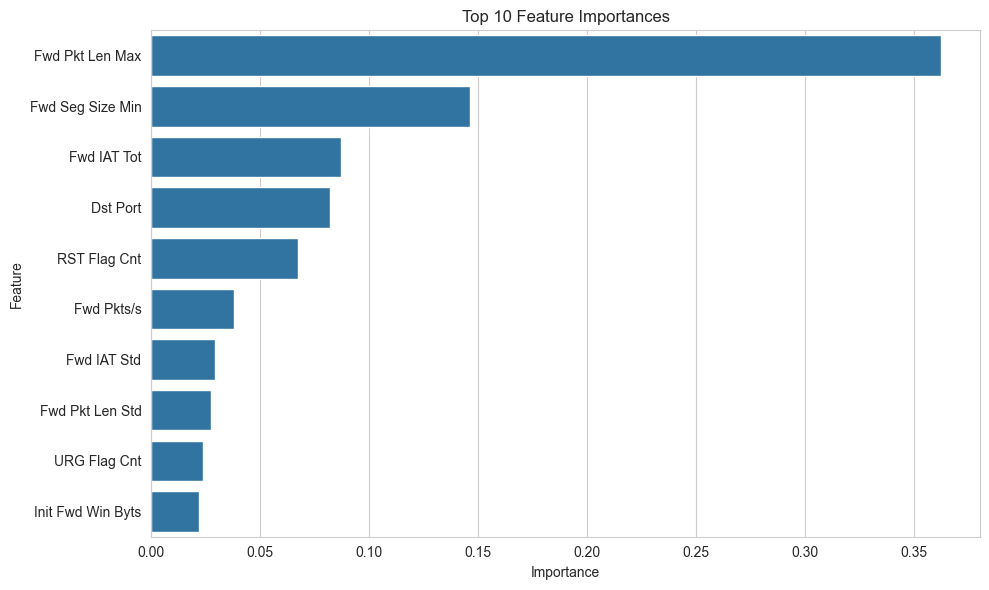

In [17]:
# 8. DETAILED FALSE POSITIVE & FALSE NEGATIVE ANALYSIS# 4. Evaluate the model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 6. ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 7. Feature Importance (Top 10)
plt.figure(figsize=(10, 6))
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(len(feature_importance))]
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False).head(10)
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

DEEP ROOT CAUSE ANALYSIS

INVESTIGATION 1: Low Confidence False Negatives (21,000+ cases)

Total False Negatives with probability < 0.3: 27005
Percentage of all test samples: 0.83%
Percentage of all actual positives: 4.91%

--- Feature Statistics for Very Low Confidence FN ---

Comparing with True Positives:
         Feature  VeryLowFN_Mean      TP_Mean   Difference  Significance_Score  VeryLowFN_Std       TP_Std
        Protocol    1.002848e+01 6.012812e+00 4.015665e+00            0.733812   5.458639e+00 3.855240e-01
        Dst Port    8.356814e+03 1.062316e+03 7.294498e+03            0.396088   1.808709e+04 3.466782e+03
Fwd Pkt Len Mean    4.484045e+01 1.869047e+01 2.614998e+01            0.393253   5.362650e+01 3.931910e+01
Bwd Pkt Len Mean    1.168540e+02 5.325881e+01 6.359523e+01            0.322509   1.722695e+02 9.595156e+01
 Fwd Pkt Len Max    1.543826e+02 7.073815e+01 8.364448e+01            0.275737   2.591187e+02 1.577271e+02
   Flow Duration    1.148621e+07 3.319417e+06 8.

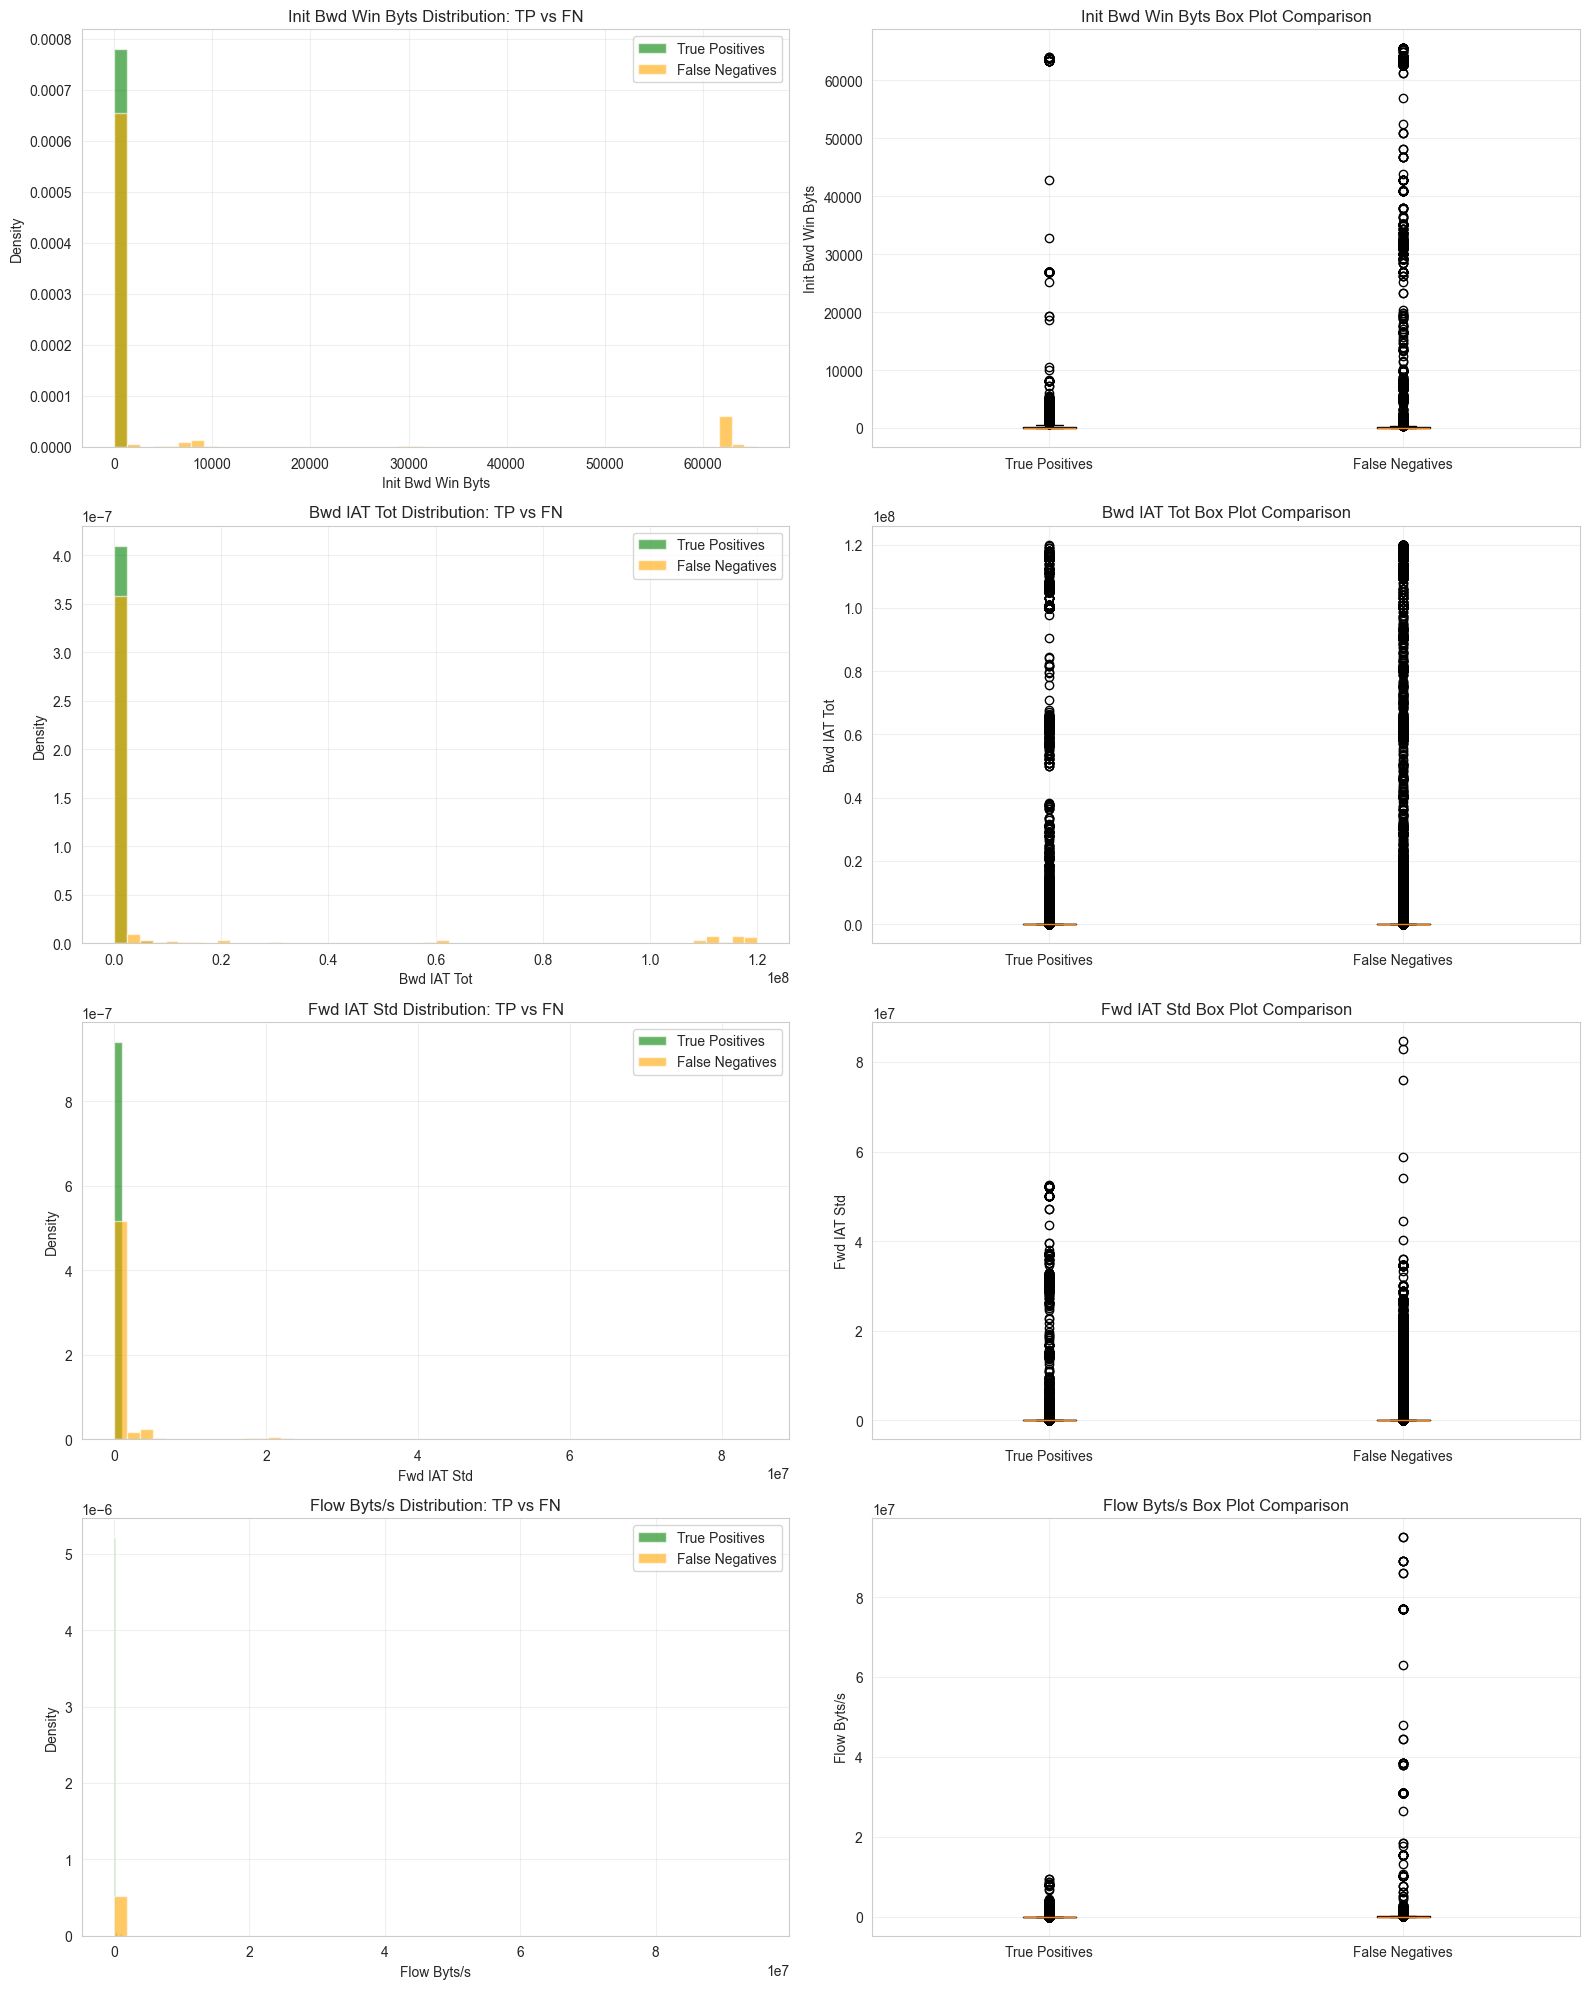


--- FALSE POSITIVE ANALYSIS ---
Distribution of key features in False Positives vs True Negatives:


Init Bwd Win Byts:
  True Negatives  - Mean: 10386.12, Median: -1.00, Std: 22175.35
  False Positives - Mean: 3152.35, Median: 0.00, Std: 12455.40
  Mean Difference: 7233.77

Bwd IAT Tot:
  True Negatives  - Mean: 8926995.08, Median: 0.00, Std: 27888267.04
  False Positives - Mean: 7668424.67, Median: 0.00, Std: 23774151.49
  Mean Difference: 1258570.41

Fwd IAT Std:
  True Negatives  - Mean: 1811980.46, Median: 0.00, Std: 471664676.18
  False Positives - Mean: 648297.57, Median: 0.00, Std: 2669503.83
  Mean Difference: 1163682.89

Dst Port:
  True Negatives  - Mean: 10723.00, Median: 443.00, Std: 20244.12
  False Positives - Mean: 14045.34, Median: 3389.00, Std: 18709.47
  Mean Difference: 3322.33


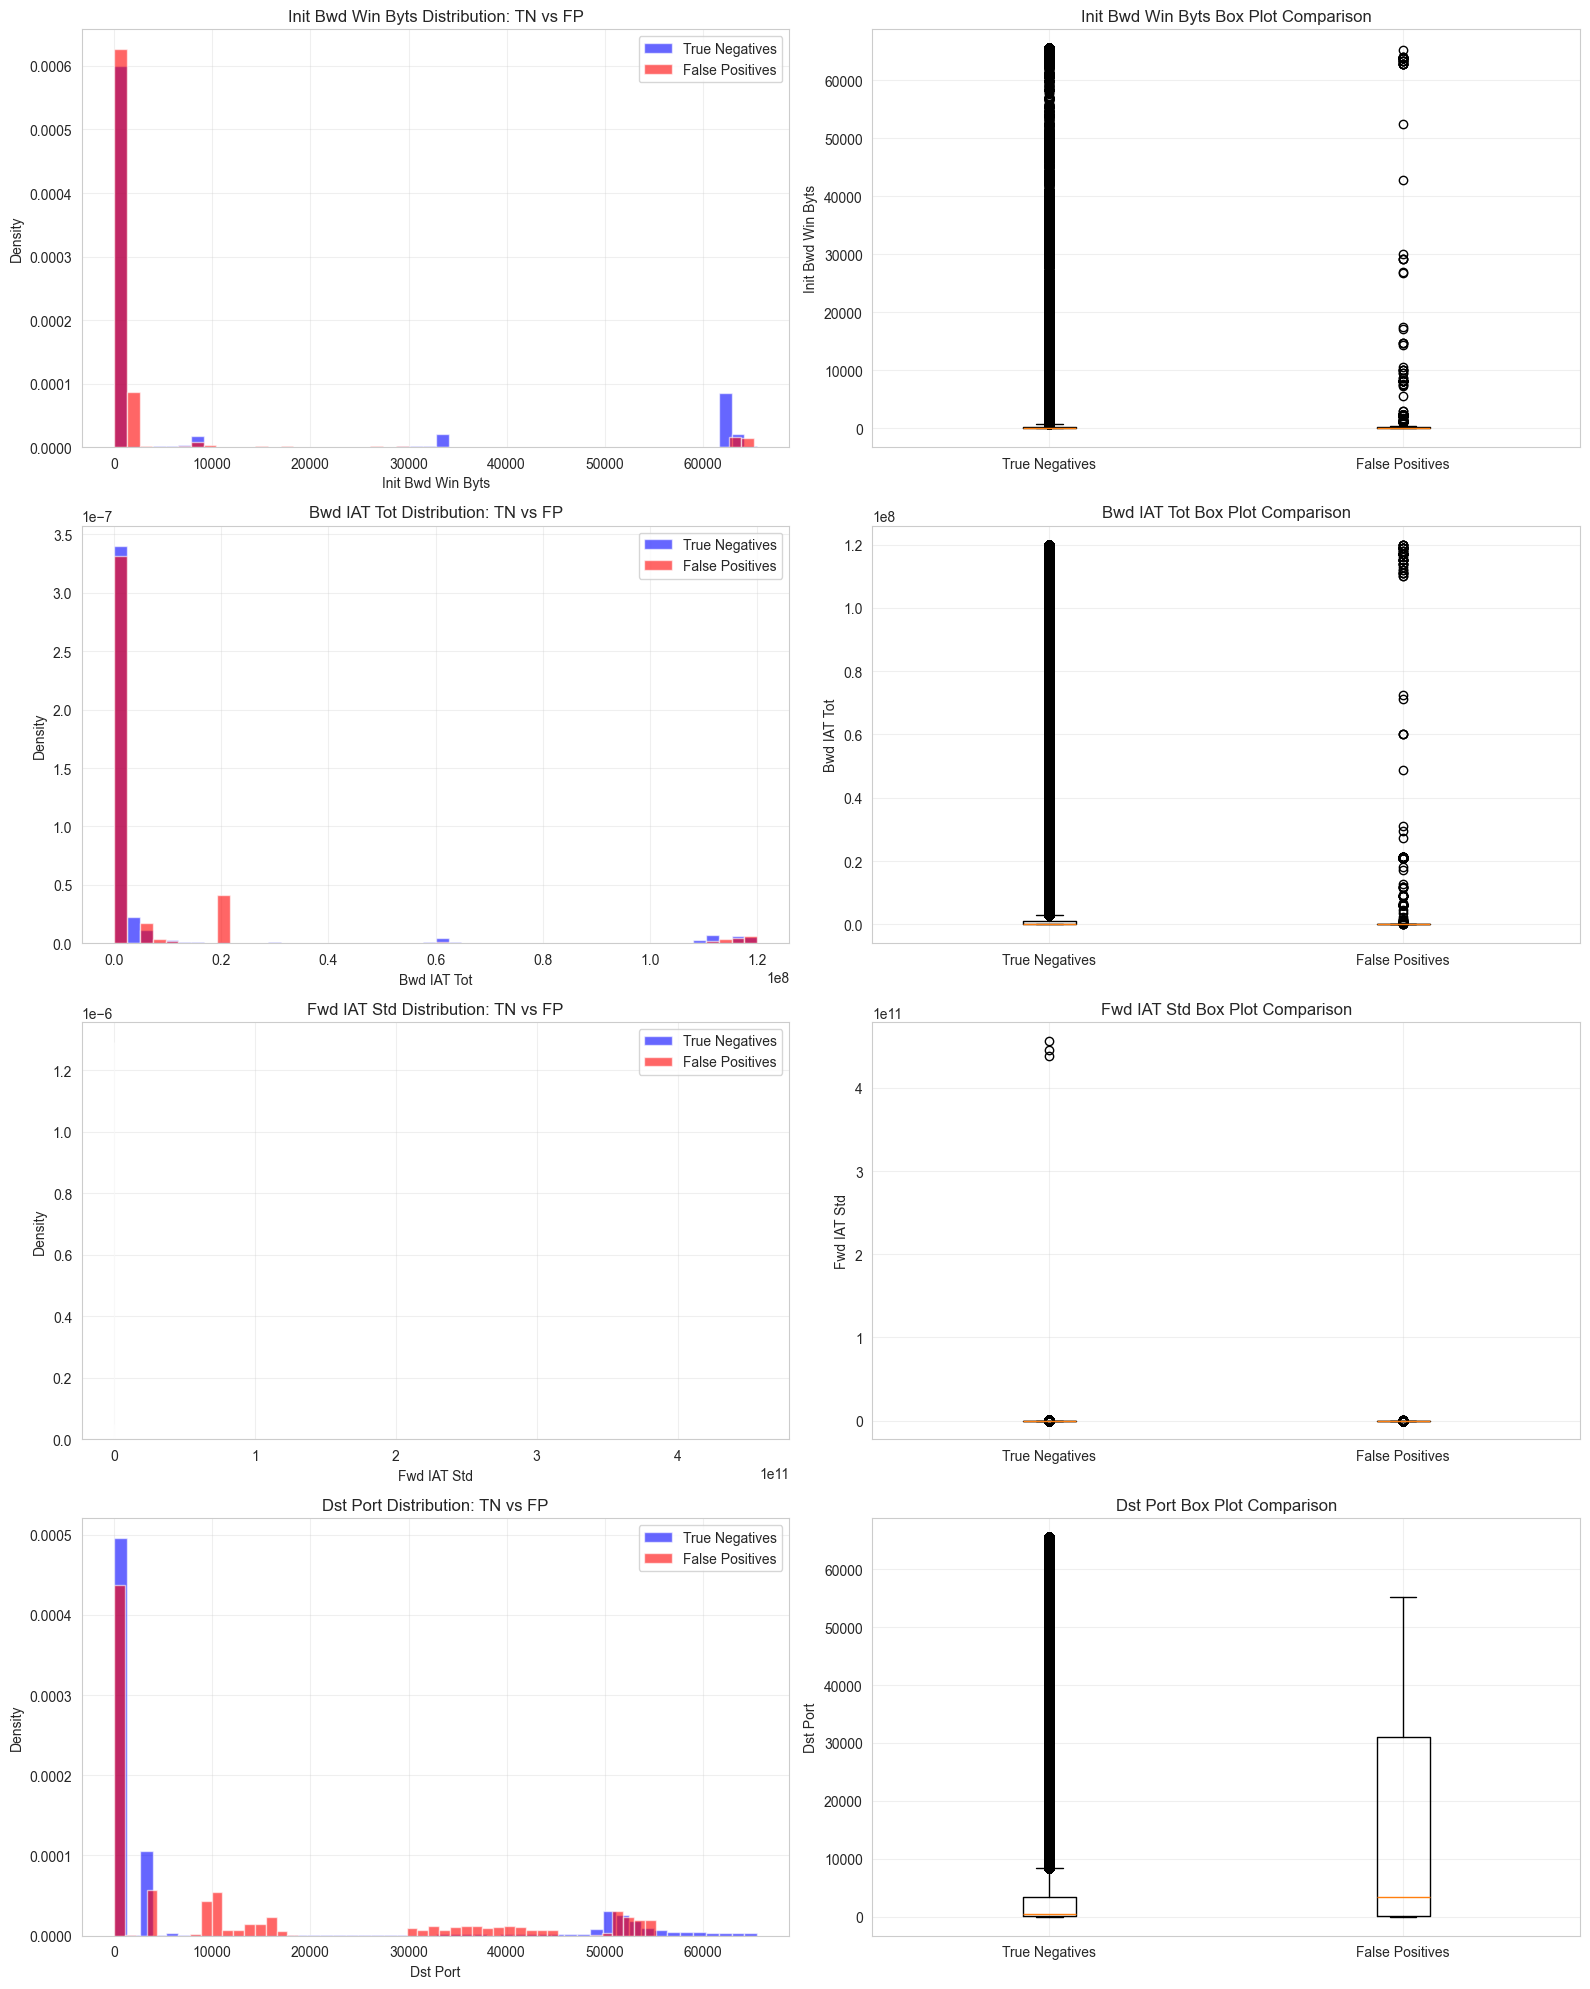


INVESTIGATION 3: Feature Correlations in Misclassified Cases


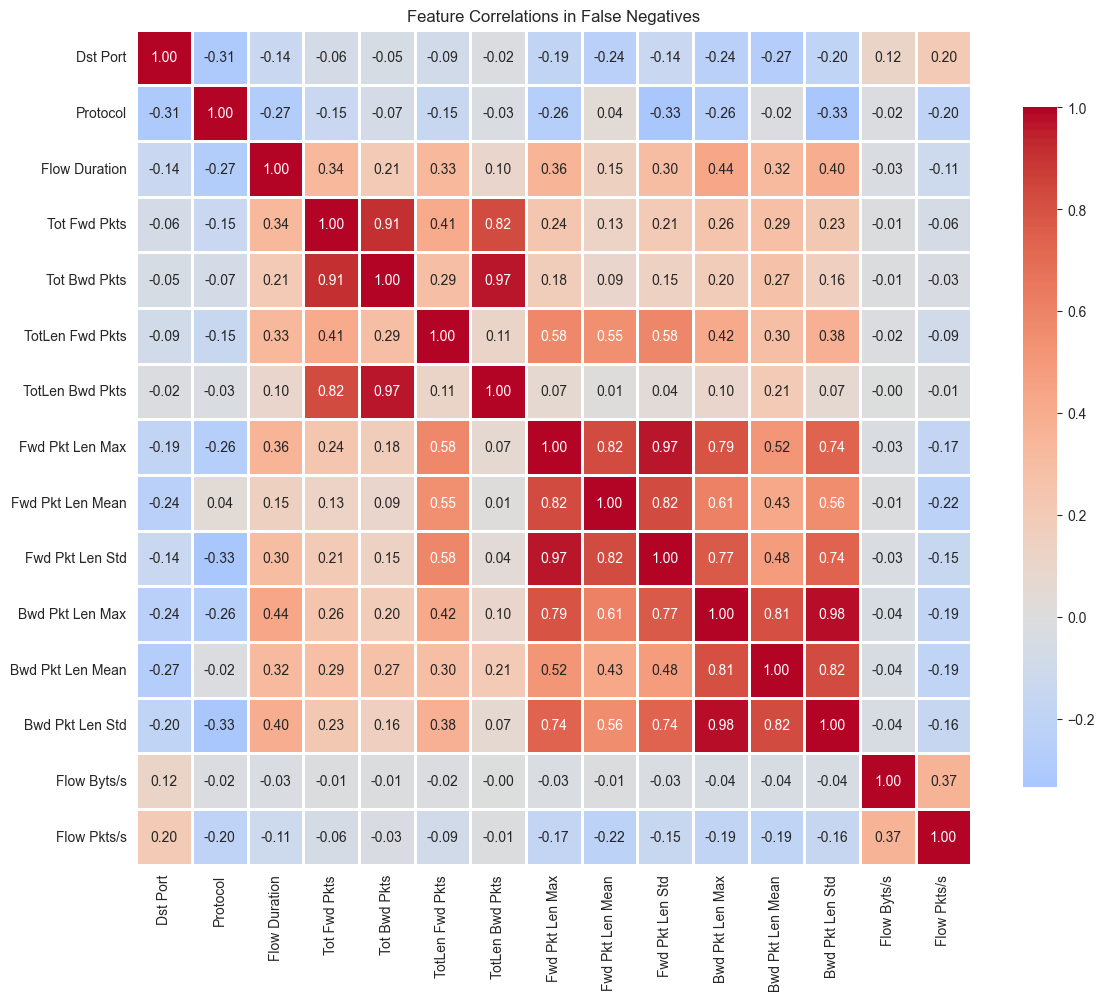


Highly Correlated Features in False Negatives (|r| > 0.7):
        Feature1         Feature2  Correlation
    Tot Fwd Pkts     Tot Bwd Pkts     0.911391
    Tot Fwd Pkts  TotLen Bwd Pkts     0.818167
    Tot Bwd Pkts  TotLen Bwd Pkts     0.967858
 Fwd Pkt Len Max Fwd Pkt Len Mean     0.821668
 Fwd Pkt Len Max  Fwd Pkt Len Std     0.967022
 Fwd Pkt Len Max  Bwd Pkt Len Max     0.793380
 Fwd Pkt Len Max  Bwd Pkt Len Std     0.738893
Fwd Pkt Len Mean  Fwd Pkt Len Std     0.822820
 Fwd Pkt Len Std  Bwd Pkt Len Max     0.768257
 Fwd Pkt Len Std  Bwd Pkt Len Std     0.735271
 Bwd Pkt Len Max Bwd Pkt Len Mean     0.809723
 Bwd Pkt Len Max  Bwd Pkt Len Std     0.978254
Bwd Pkt Len Mean  Bwd Pkt Len Std     0.822039

INVESTIGATION 4: Outlier Detection in Misclassified Cases

Outlier Analysis (using IQR method):
         Feature  FN_Outliers  FN_Outlier_Pct  TP_Outliers  TP_Outlier_Pct  FP_Outliers  FP_Outlier_Pct
 TotLen Fwd Pkts         7128       23.069454        92902       17.908854       

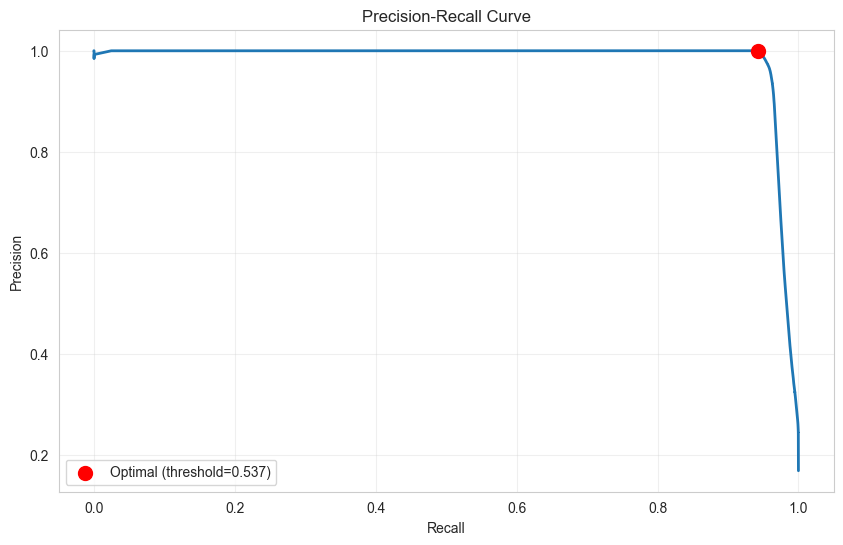


INVESTIGATION 6: Class Distribution Analysis

Training Set Class Distribution:
Label_Binary
0    10787766
1     2198588
Name: count, dtype: int64
Class 0: 83.07%
Class 1: 16.93%
Imbalance Ratio: 4.91:1

Test Set Class Distribution:
Label_Binary
0    2696942
1     549647
Name: count, dtype: int64
Class 0: 83.07%
Class 1: 16.93%

KEY INSIGHTS & RECOMMENDATIONS


In [19]:
# 13. DEEP DIVE INVESTIGATION - ROOT CAUSE ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("DEEP ROOT CAUSE ANALYSIS")
print("="*80)

# Key findings from your screenshots:
# 1. FALSE POSITIVES: Most occur at medium confidence (0.5-0.7)
# 2. FALSE NEGATIVES: Heavily concentrated at very low confidence (0-0.3) - over 21,000 cases!
# 3. Top differentiating features identified

# ============================================================================
# INVESTIGATION 1: WHY ARE THERE SO MANY LOW-CONFIDENCE FALSE NEGATIVES?
# ============================================================================

print("\n" + "="*80)
print("INVESTIGATION 1: Low Confidence False Negatives (21,000+ cases)")
print("="*80)

# Analyze the very low confidence false negatives (0-0.3 range)
very_low_fn = false_negatives[false_negatives['Probability'] < 0.3]

print(f"\nTotal False Negatives with probability < 0.3: {len(very_low_fn)}")
print(f"Percentage of all test samples: {len(very_low_fn)/len(results_df)*100:.2f}%")
print(f"Percentage of all actual positives: {len(very_low_fn)/len(results_df[results_df['Actual']==1])*100:.2f}%")

# Statistical comparison
print("\n--- Feature Statistics for Very Low Confidence FN ---")
print("\nComparing with True Positives:")

feature_cols = [col for col in results_df.columns if col not in ['Actual', 'Predicted', 'Probability', 'Prediction_Type']]

low_conf_analysis = []
for col in feature_cols[:15]:  # Top 15 features
    if results_df[col].dtype in ['int64', 'float64']:
        very_low_fn_mean = very_low_fn[col].mean()
        tp_mean = true_positives[col].mean()
        very_low_fn_std = very_low_fn[col].std()
        tp_std = true_positives[col].std()

        # Calculate z-score like metric
        diff = abs(very_low_fn_mean - tp_mean)
        combined_std = np.sqrt(very_low_fn_std**2 + tp_std**2)
        significance = diff / (combined_std + 0.0001)

        low_conf_analysis.append({
            'Feature': col,
            'VeryLowFN_Mean': very_low_fn_mean,
            'TP_Mean': tp_mean,
            'Difference': diff,
            'Significance_Score': significance,
            'VeryLowFN_Std': very_low_fn_std,
            'TP_Std': tp_std
        })

low_conf_df = pd.DataFrame(low_conf_analysis).sort_values('Significance_Score', ascending=False)
print(low_conf_df.head(10).to_string(index=False))

# ============================================================================
# INVESTIGATION 2: ANALYZE THE TOP PROBLEMATIC FEATURES
# ============================================================================

print("\n" + "="*80)
print("INVESTIGATION 2: Deep Dive on Top Problematic Features")
print("="*80)

# From your screenshots, the top features are:
# False Negatives: Init Bwd Win Byts, Bwd IAT Tot, Fwd IAT Std, Flow Byts/s
# False Positives: Init Bwd Win Byts, Bwd IAT Tot, Fwd IAT Std, Dst Port

top_fn_features = ['Init Bwd Win Byts', 'Bwd IAT Tot', 'Fwd IAT Std', 'Flow Byts/s']
top_fp_features = ['Init Bwd Win Byts', 'Bwd IAT Tot', 'Fwd IAT Std', 'Dst Port']

# Check which features exist in your data
top_fn_features = [f for f in top_fn_features if f in feature_cols]
top_fp_features = [f for f in top_fp_features if f in feature_cols]

if len(top_fn_features) > 0:
    print("\n--- FALSE NEGATIVE ANALYSIS ---")
    print("Distribution of key features in False Negatives vs True Positives:\n")

    fig, axes = plt.subplots(len(top_fn_features), 2, figsize=(16, 5*len(top_fn_features)))
    if len(top_fn_features) == 1:
        axes = axes.reshape(1, -1)

    for idx, feature in enumerate(top_fn_features):
        # Histogram comparison
        axes[idx, 0].hist(true_positives[feature].dropna(), bins=50, alpha=0.6,
                         label='True Positives', color='green', density=True)
        axes[idx, 0].hist(false_negatives[feature].dropna(), bins=50, alpha=0.6,
                         label='False Negatives', color='orange', density=True)
        axes[idx, 0].set_xlabel(feature)
        axes[idx, 0].set_ylabel('Density')
        axes[idx, 0].set_title(f'{feature} Distribution: TP vs FN')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        # Box plot
        data_to_plot = [true_positives[feature].dropna(), false_negatives[feature].dropna()]
        axes[idx, 1].boxplot(data_to_plot, labels=['True Positives', 'False Negatives'])
        axes[idx, 1].set_ylabel(feature)
        axes[idx, 1].set_title(f'{feature} Box Plot Comparison')
        axes[idx, 1].grid(True, alpha=0.3)

        # Print statistics
        print(f"\n{feature}:")
        print(f"  True Positives  - Mean: {true_positives[feature].mean():.2f}, Median: {true_positives[feature].median():.2f}, Std: {true_positives[feature].std():.2f}")
        print(f"  False Negatives - Mean: {false_negatives[feature].mean():.2f}, Median: {false_negatives[feature].median():.2f}, Std: {false_negatives[feature].std():.2f}")
        print(f"  Mean Difference: {abs(true_positives[feature].mean() - false_negatives[feature].mean()):.2f}")

    plt.tight_layout()
    plt.show()

if len(top_fp_features) > 0:
    print("\n--- FALSE POSITIVE ANALYSIS ---")
    print("Distribution of key features in False Positives vs True Negatives:\n")

    fig, axes = plt.subplots(len(top_fp_features), 2, figsize=(16, 5*len(top_fp_features)))
    if len(top_fp_features) == 1:
        axes = axes.reshape(1, -1)

    for idx, feature in enumerate(top_fp_features):
        # Histogram comparison
        axes[idx, 0].hist(true_negatives[feature].dropna(), bins=50, alpha=0.6,
                         label='True Negatives', color='blue', density=True)
        axes[idx, 0].hist(false_positives[feature].dropna(), bins=50, alpha=0.6,
                         label='False Positives', color='red', density=True)
        axes[idx, 0].set_xlabel(feature)
        axes[idx, 0].set_ylabel('Density')
        axes[idx, 0].set_title(f'{feature} Distribution: TN vs FP')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        # Box plot
        data_to_plot = [true_negatives[feature].dropna(), false_positives[feature].dropna()]
        axes[idx, 1].boxplot(data_to_plot, labels=['True Negatives', 'False Positives'])
        axes[idx, 1].set_ylabel(feature)
        axes[idx, 1].set_title(f'{feature} Box Plot Comparison')
        axes[idx, 1].grid(True, alpha=0.3)

        # Print statistics
        print(f"\n{feature}:")
        print(f"  True Negatives  - Mean: {true_negatives[feature].mean():.2f}, Median: {true_negatives[feature].median():.2f}, Std: {true_negatives[feature].std():.2f}")
        print(f"  False Positives - Mean: {false_positives[feature].mean():.2f}, Median: {false_positives[feature].median():.2f}, Std: {false_positives[feature].std():.2f}")
        print(f"  Mean Difference: {abs(true_negatives[feature].mean() - false_positives[feature].mean()):.2f}")

    plt.tight_layout()
    plt.show()

# ============================================================================
# INVESTIGATION 3: CORRELATION ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("INVESTIGATION 3: Feature Correlations in Misclassified Cases")
print("="*80)

# Check correlations among top features in false negatives
if len(false_negatives) > 10 and len(feature_cols) > 1:
    fn_corr = false_negatives[feature_cols[:15]].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(fn_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlations in False Negatives')
    plt.tight_layout()
    plt.show()

    # Find highly correlated features
    high_corr_pairs = []
    for i in range(len(fn_corr.columns)):
        for j in range(i+1, len(fn_corr.columns)):
            if abs(fn_corr.iloc[i, j]) > 0.7:
                high_corr_pairs.append({
                    'Feature1': fn_corr.columns[i],
                    'Feature2': fn_corr.columns[j],
                    'Correlation': fn_corr.iloc[i, j]
                })

    if high_corr_pairs:
        print("\nHighly Correlated Features in False Negatives (|r| > 0.7):")
        print(pd.DataFrame(high_corr_pairs).to_string(index=False))

# ============================================================================
# INVESTIGATION 4: OUTLIER ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("INVESTIGATION 4: Outlier Detection in Misclassified Cases")
print("="*80)

# Check if false negatives contain unusual outliers
def count_outliers(data, feature):
    """Count outliers using IQR method"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return len(outliers)

outlier_summary = []
for feature in feature_cols[:10]:
    if results_df[feature].dtype in ['int64', 'float64']:
        fn_outliers = count_outliers(false_negatives, feature)
        tp_outliers = count_outliers(true_positives, feature)
        fp_outliers = count_outliers(false_positives, feature)
        tn_outliers = count_outliers(true_negatives, feature)

        outlier_summary.append({
            'Feature': feature,
            'FN_Outliers': fn_outliers,
            'FN_Outlier_Pct': (fn_outliers/len(false_negatives)*100) if len(false_negatives) > 0 else 0,
            'TP_Outliers': tp_outliers,
            'TP_Outlier_Pct': (tp_outliers/len(true_positives)*100) if len(true_positives) > 0 else 0,
            'FP_Outliers': fp_outliers,
            'FP_Outlier_Pct': (fp_outliers/len(false_positives)*100) if len(false_positives) > 0 else 0
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values('FN_Outlier_Pct', ascending=False)
print("\nOutlier Analysis (using IQR method):")
print(outlier_df.to_string(index=False))

# ============================================================================
# INVESTIGATION 5: THRESHOLD ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("INVESTIGATION 5: Optimal Threshold Analysis")
print("="*80)

from sklearn.metrics import precision_recall_curve, f1_score

# Calculate precision-recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find optimal threshold for F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = f1_scores[optimal_idx]

print(f"\nCurrent threshold: 0.5")
print(f"Optimal threshold for F1: {optimal_threshold:.4f}")
print(f"F1 at current threshold: {f1_score(y_test, y_pred):.4f}")
print(f"F1 at optimal threshold: {optimal_f1:.4f}")

# Test different thresholds
print("\n--- Performance at Different Thresholds ---")
test_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in test_thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    fp_count = np.sum((y_test == 0) & (y_pred_thresh == 1))
    fn_count = np.sum((y_test == 1) & (y_pred_thresh == 0))
    tp_count = np.sum((y_test == 1) & (y_pred_thresh == 1))
    tn_count = np.sum((y_test == 0) & (y_pred_thresh == 0))

    accuracy = (tp_count + tn_count) / len(y_test)
    precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0
    recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nThreshold: {thresh}")
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(f"  FP: {fp_count}, FN: {fn_count}, TP: {tp_count}, TN: {tn_count}")

# Plot precision-recall curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, linewidth=2)
plt.scatter([recalls[optimal_idx]], [precisions[optimal_idx]],
           color='red', s=100, zorder=5, label=f'Optimal (threshold={optimal_threshold:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# INVESTIGATION 6: CLASS IMBALANCE CHECK
# ============================================================================

print("\n" + "="*80)
print("INVESTIGATION 6: Class Distribution Analysis")
print("="*80)

print("\nTraining Set Class Distribution:")
train_class_dist = pd.Series(y_train).value_counts()
print(train_class_dist)
print(f"Class 0: {train_class_dist[0]/len(y_train)*100:.2f}%")
print(f"Class 1: {train_class_dist[1]/len(y_train)*100:.2f}%")
print(f"Imbalance Ratio: {train_class_dist[0]/train_class_dist[1]:.2f}:1")

print("\nTest Set Class Distribution:")
test_class_dist = pd.Series(y_test).value_counts()
print(test_class_dist)
print(f"Class 0: {test_class_dist[0]/len(y_test)*100:.2f}%")
print(f"Class 1: {test_class_dist[1]/len(y_test)*100:.2f}%")

print("\n" + "="*80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)

FEATURE SCALING DIAGNOSTIC

--- FEATURE SCALE ANALYSIS ---

         Feature           Min          Max         Mean          Std        Range  Order_of_Magnitude
        Dst Port  0.000000e+00 6.553500e+04 9.165369e+03 1.892337e+04 6.553500e+04                   4
        Protocol  0.000000e+00 1.700000e+01 8.753519e+00 4.919758e+00 1.700000e+01                   1
   Flow Duration -9.190110e+11 1.200000e+08 1.177970e+07 5.216614e+08 9.191310e+11                   8
    Tot Fwd Pkts  1.000000e+00 3.096290e+05 2.302744e+01 1.496346e+03 3.096280e+05                   5
    Tot Bwd Pkts  0.000000e+00 1.231180e+05 6.304712e+00 1.634551e+02 1.231180e+05                   5
 TotLen Fwd Pkts  0.000000e+00 1.443918e+08 9.555569e+02 6.317451e+04 1.443918e+08                   8
 TotLen Bwd Pkts  0.000000e+00 1.563604e+08 4.718880e+03 2.329667e+05 1.563604e+08                   8
 Fwd Pkt Len Max  0.000000e+00 6.444000e+04 2.007404e+02 3.039592e+02 6.444000e+04                   4
Fwd Pkt Len M

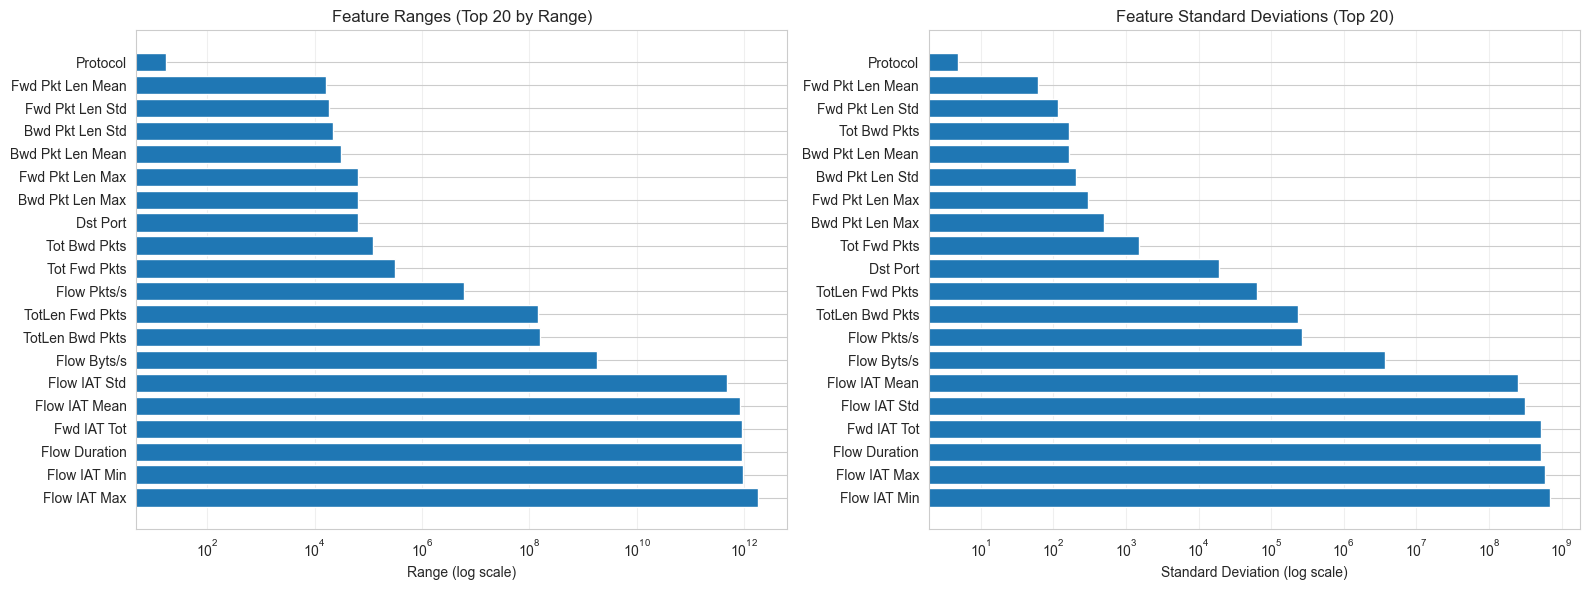


PROBLEMATIC FEATURES SCALE CHECK

Features causing most errors and their scales:

Flow Byts/s:
  Range: 1,806,642,857
  Mean:  255,424
  Std:   3,701,491
  Scale: 10^9

DISTRIBUTION SKEWNESS CHECK
          Feature    Skewness Needs_Log
Init Bwd Win Byts    2.133767       YES
      Bwd IAT Tot    3.623092       YES
      Fwd IAT Std 1254.429227       YES
      Flow Byts/s   87.147383       YES

Skewness interpretation:
  |skew| < 0.5  : Fairly symmetric (normal-ish)
  |skew| 0.5-1  : Moderately skewed
  |skew| > 1    : Highly skewed → LOG TRANSFORM RECOMMENDED


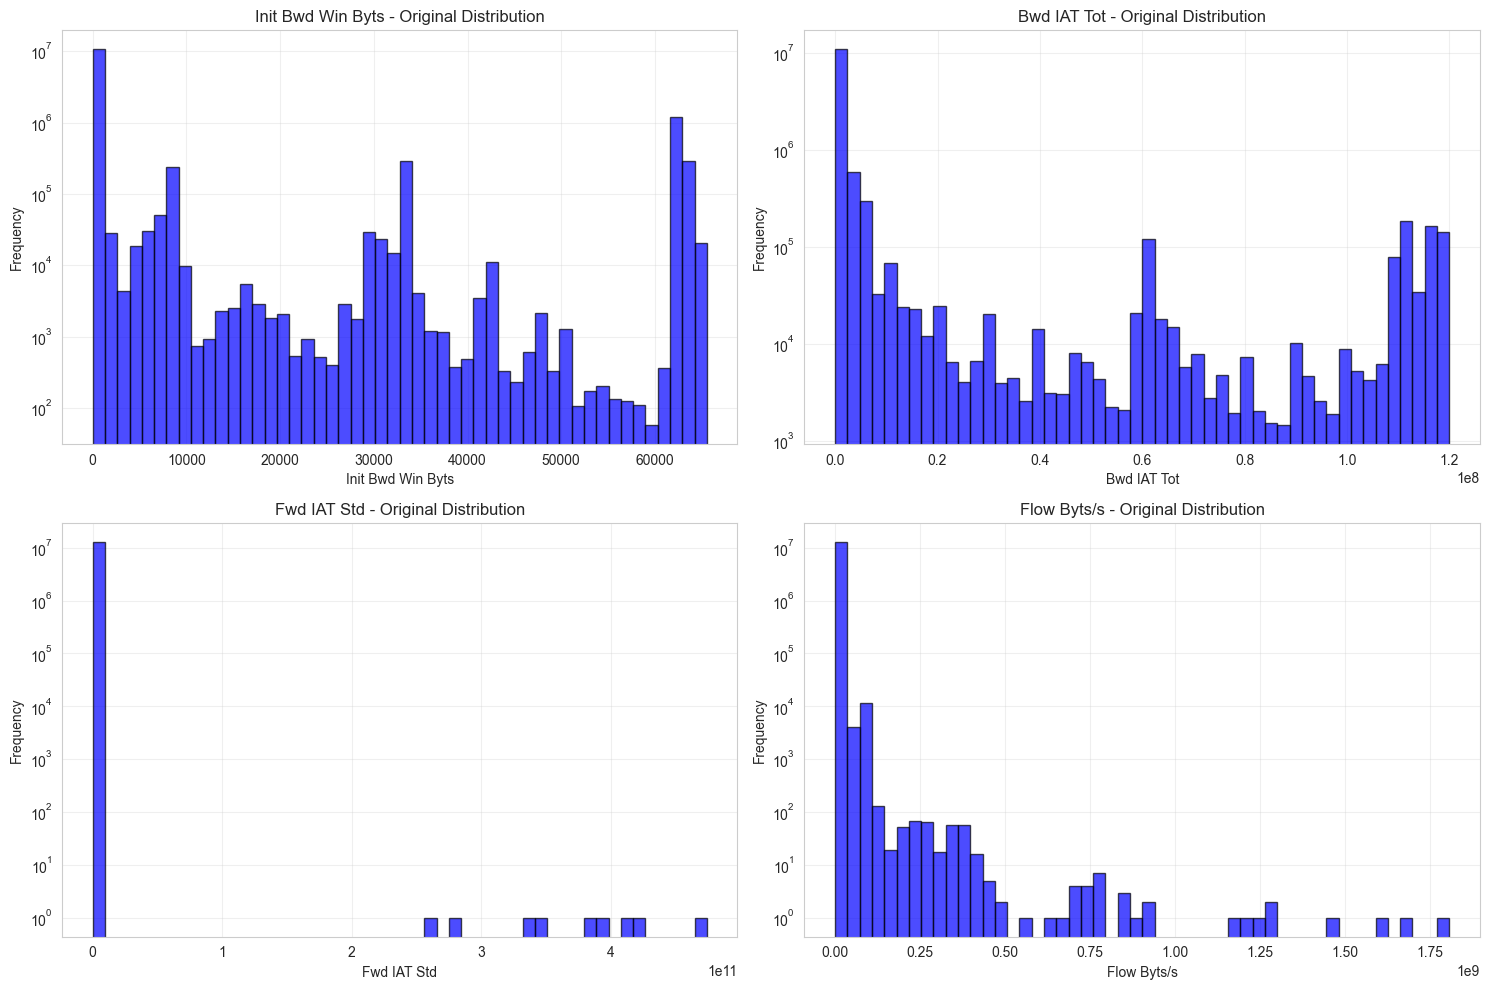


CONCLUSION

╔════════════════════════════════════════════════════════════════════════════╗
║  ⚠️  SCALING IS DEFINITELY PART OF THE PROBLEM  ⚠️                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Your features have VASTLY different scales (>1000x difference).
This causes XGBoost to:
  1. Prioritize large-scale features in splits
  2. Miss patterns in small-scale features
  3. Create suboptimal decision boundaries

RECOMMENDATION: Apply scaling/transformation BEFORE training.



In [20]:
# ============================================================================
# DIAGNOSTIC: IS SCALING THE PROBLEM?
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("FEATURE SCALING DIAGNOSTIC")
print("="*80)

# Get numeric features only
feature_cols = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]

# Step 1: Analyze feature scales
print("\n--- FEATURE SCALE ANALYSIS ---\n")

scale_analysis = []
for col in feature_cols[:20]:  # Check first 20 features
    col_min = X_train[col].min()
    col_max = X_train[col].max()
    col_mean = X_train[col].mean()
    col_std = X_train[col].std()
    col_range = col_max - col_min

    scale_analysis.append({
        'Feature': col,
        'Min': col_min,
        'Max': col_max,
        'Mean': col_mean,
        'Std': col_std,
        'Range': col_range,
        'Order_of_Magnitude': int(np.log10(abs(col_max) + 1))
    })

scale_df = pd.DataFrame(scale_analysis)
print(scale_df.to_string(index=False))

# Step 2: Check for extreme variance in scales
print("\n" + "="*80)
print("SCALE VARIANCE CHECK")
print("="*80)

orders_of_magnitude = scale_df['Order_of_Magnitude'].values
magnitude_range = orders_of_magnitude.max() - orders_of_magnitude.min()

print(f"\nSmallest feature scale: 10^{orders_of_magnitude.min()}")
print(f"Largest feature scale:  10^{orders_of_magnitude.max()}")
print(f"Magnitude difference:   {magnitude_range} orders of magnitude")

if magnitude_range > 3:
    print("\n⚠️  WARNING: Features differ by more than 3 orders of magnitude!")
    print("   This is likely causing the model to miss patterns in smaller-scale features.")
    print("   SCALING IS HIGHLY RECOMMENDED.")
else:
    print("\n✓ Feature scales are relatively similar.")

# Step 3: Visualize scale differences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature ranges (log scale)
top_20_features = scale_df.nlargest(20, 'Range')
axes[0].barh(range(len(top_20_features)), top_20_features['Range'])
axes[0].set_yticks(range(len(top_20_features)))
axes[0].set_yticklabels(top_20_features['Feature'])
axes[0].set_xlabel('Range (log scale)')
axes[0].set_xscale('log')
axes[0].set_title('Feature Ranges (Top 20 by Range)')
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: Standard deviations (log scale)
top_20_std = scale_df.nlargest(20, 'Std')
axes[1].barh(range(len(top_20_std)), top_20_std['Std'])
axes[1].set_yticks(range(len(top_20_std)))
axes[1].set_yticklabels(top_20_std['Feature'])
axes[1].set_xlabel('Standard Deviation (log scale)')
axes[1].set_xscale('log')
axes[1].set_title('Feature Standard Deviations (Top 20)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Step 4: Check if problematic features are unscaled
print("\n" + "="*80)
print("PROBLEMATIC FEATURES SCALE CHECK")
print("="*80)

problematic_features = ['Init Bwd Win Byts', 'Bwd IAT Tot', 'Fwd IAT Std', 'Flow Byts/s']
problematic_features = [f for f in problematic_features if f in feature_cols]

print("\nFeatures causing most errors and their scales:")
for feat in problematic_features:
    feat_info = scale_df[scale_df['Feature'] == feat]
    if len(feat_info) > 0:
        print(f"\n{feat}:")
        print(f"  Range: {feat_info['Range'].values[0]:,.0f}")
        print(f"  Mean:  {feat_info['Mean'].values[0]:,.0f}")
        print(f"  Std:   {feat_info['Std'].values[0]:,.0f}")
        print(f"  Scale: 10^{feat_info['Order_of_Magnitude'].values[0]}")

# Step 5: Check distribution shapes (skewness)
print("\n" + "="*80)
print("DISTRIBUTION SKEWNESS CHECK")
print("="*80)

skewness_analysis = []
for col in problematic_features:
    if col in X_train.columns:
        from scipy.stats import skew
        col_skew = skew(X_train[col].dropna())
        skewness_analysis.append({
            'Feature': col,
            'Skewness': col_skew,
            'Needs_Log': 'YES' if abs(col_skew) > 1 else 'NO'
        })

skew_df = pd.DataFrame(skewness_analysis)
print(skew_df.to_string(index=False))
print("\nSkewness interpretation:")
print("  |skew| < 0.5  : Fairly symmetric (normal-ish)")
print("  |skew| 0.5-1  : Moderately skewed")
print("  |skew| > 1    : Highly skewed → LOG TRANSFORM RECOMMENDED")

# Step 6: Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feat in enumerate(problematic_features[:4]):
    if feat in X_train.columns:
        # Original distribution
        axes[idx].hist(X_train[feat].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
        axes[idx].set_xlabel(feat)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{feat} - Original Distribution')
        axes[idx].set_yscale('log')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

if magnitude_range > 3:
    print("""
╔════════════════════════════════════════════════════════════════════════════╗
║  ⚠️  SCALING IS DEFINITELY PART OF THE PROBLEM  ⚠️                          ║
╚════════════════════════════════════════════════════════════════════════════╝

Your features have VASTLY different scales (>1000x difference).
This causes XGBoost to:
  1. Prioritize large-scale features in splits
  2. Miss patterns in small-scale features
  3. Create suboptimal decision boundaries

RECOMMENDATION: Apply scaling/transformation BEFORE training.
""")
else:
    print("""
✓ Scaling may help but is not the primary issue.
  The false negatives are more likely due to missing patterns
  or insufficient model complexity.
""")